# 1. Data Loading

This section is responsible for importing necessary libraries, loading the dataset from a CSV file into a pandas DataFrame, and performing an initial inspection of the data's structure and contents.

**Requirements:**
- `pandas` library for data manipulation.
- The `heartriskanalysis.csv` file should be available in the specified path.

In [54]:
import pandas as pd

In [55]:
df=pd.read_csv("/content/heartriskanalysis.csv")

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

In [57]:
df.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [58]:
df=df.drop(columns=['Country'])

# 2. Initial Data Cleaning & Preprocessing

This section focuses on handling categorical features by dropping irrelevant columns and converting others into a numerical format using one-hot encoding. Specifically, it removes the 'Country' column and transforms 'Sex', 'Continent', and 'Hemisphere' into dummy variables to prepare them for modeling.

**Requirements:**
- `pandas` library for data manipulation.
- The DataFrame `df` loaded in the previous section.

In [59]:
df.select_dtypes(include='object').columns

Index(['Patient ID', 'Sex', 'Blood Pressure', 'Diet', 'Continent',
       'Hemisphere'],
      dtype='object')

In [60]:
df=pd.get_dummies(df,columns=['Sex','Continent','Hemisphere'],drop_first=True)*1

In [61]:
df.select_dtypes(include='object').columns

Index(['Patient ID', 'Blood Pressure', 'Diet'], dtype='object')

In [62]:
df.head()

,Patient ID,Age,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,...,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk,Sex_Male,Continent_Asia,Continent_Australia,Continent_Europe,Continent_North America,Continent_South America,Hemisphere_Southern Hemisphere
0,BMW7812,67,208,158/88,72,0,0,1,0,0,...,0,6,0,1,0,0,0,0,1,1
1,CZE1114,21,389,165/93,98,1,1,1,1,1,...,1,7,0,1,0,0,0,1,0,0
2,BNI9906,21,324,174/99,72,1,0,0,0,0,...,4,4,0,0,0,0,1,0,0,0
3,JLN3497,84,383,163/100,73,1,1,1,0,1,...,3,4,0,1,0,0,0,1,0,0
4,GFO8847,66,318,91/88,93,1,1,1,1,0,...,1,5,0,1,1,0,0,0,0,0


In [63]:
df[['Systolic','Diastolic']]=df['Blood Pressure'].str.split('/',expand=True).astype(int)

# 3. Blood Pressure & Patient ID Handling

This section processes the 'Blood Pressure' column, splitting it into 'Systolic' and 'Diastolic' components and converting them to integer data types. It then removes the original 'Blood Pressure' column and the unique 'Patient ID' column, as these are either transformed or deemed irrelevant for the predictive modeling task.

**Requirements:**
- `pandas` library for string operations and data type conversion.
- The DataFrame `df` containing 'Blood Pressure' and 'Patient ID' columns.

In [64]:
df.drop(columns=['Blood Pressure','Patient ID'],inplace=True)

In [65]:
df.columns

Index(['Age', 'Cholesterol', 'Heart Rate', 'Diabetes', 'Family History',
       'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week',
       'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day',
       'Heart Attack Risk', 'Sex_Male', 'Continent_Asia',
       'Continent_Australia', 'Continent_Europe', 'Continent_North America',
       'Continent_South America', 'Hemisphere_Southern Hemisphere', 'Systolic',
       'Diastolic'],
      dtype='object')

In [66]:
df['Diet'].value_counts()

,count
Diet,
Healthy,2960
Average,2912
Unhealthy,2891


# 4. Categorical Feature Encoding (Diet)

This section handles the 'Diet' categorical feature by mapping its string values ('Healthy', 'Average', 'Unhealthy') to numerical representations (1, 2, 3 respectively). After encoding, the original 'Diet' column is dropped, ensuring all features are in a numerical format suitable for machine learning algorithms.

**Requirements:**
- `pandas` library for mapping and column manipulation.
- The DataFrame `df` containing the 'Diet' column.

In [67]:
categorymap={'Healthy':1,'Average':2,'Unhealthy':3}
df['Diet_encoded']=df['Diet'].map(categorymap)

In [68]:
df.drop(columns=['Diet'],inplace=True)

In [69]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

In [70]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

In [71]:
len(df.select_dtypes(include='number').columns)

29

# 5. Data Inspection & Summary

This section provides a comprehensive overview of the preprocessed DataFrame. It checks the number of numerical columns, the overall shape of the DataFrame, identifies any missing (null) values, and generates descriptive statistics for all numerical columns. Finally, it checks for duplicate rows within the dataset.

**Requirements:**
- `pandas` library for DataFrame inspection methods.
- The DataFrame `df` after all preprocessing steps.

In [72]:
df.shape

(8763, 29)

In [73]:
df.isnull().sum()

,0
Age,0
Cholesterol,0
Heart Rate,0
Diabetes,0
Family History,0
Smoking,0
Obesity,0
Alcohol Consumption,0
Exercise Hours Per Week,0
Previous Heart Problems,0


In [74]:
df.describe()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,...,Sex_Male,Continent_Asia,Continent_Australia,Continent_Europe,Continent_North America,Continent_South America,Hemisphere_Southern Hemisphere,Systolic,Diastolic,Diet_encoded
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,...,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,53.707977,259.877211,75.021682,0.652288,0.492982,0.896839,0.501426,0.598083,10.014284,0.495835,...,0.697364,0.290197,0.100879,0.255734,0.098140,0.155426,0.354102,135.075659,85.156111,1.992126
std,21.249509,80.863276,20.550948,0.476271,0.499979,0.304186,0.500026,0.490313,5.783745,0.500011,...,0.459425,0.453879,0.301185,0.436298,0.297521,0.362331,0.478268,26.349976,14.676565,0.817134
min,18.000000,120.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002442,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,90.000000,60.000000,1.000000
25%,35.000000,192.000000,57.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.981579,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,112.000000,72.000000,1.000000
50%,54.000000,259.000000,75.000000,1.000000,0.000000,1.000000,1.000000,1.000000,10.069559,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,135.000000,85.000000,2.000000
75%,72.000000,330.000000,93.000000,1.000000,1.000000,1.000000,1.000000,1.000000,15.050018,1.000000,...,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,158.000000,98.000000,3.000000
max,90.000000,400.000000,110.000000,1.000000,1.000000,1.000000,1.000000,1.000000,19.998709,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,180.000000,110.000000,3.000000


In [75]:
df.duplicated().any()

np.False_

In [76]:
X=df.drop(columns=['Heart Attack Risk'])
y=df['Heart Attack Risk']

# 6. Initial Data Splitting and Scaling

This section prepares the data for model training by separating features (X) from the target variable (y). It then applies `StandardScaler` to normalize the feature set, ensuring all features contribute equally to the model by having a mean of 0 and a variance of 1. The first few rows of the scaled data are displayed.

**Requirements:**
- `sklearn.preprocessing.StandardScaler` for feature scaling.
- `pandas` for DataFrame operations.

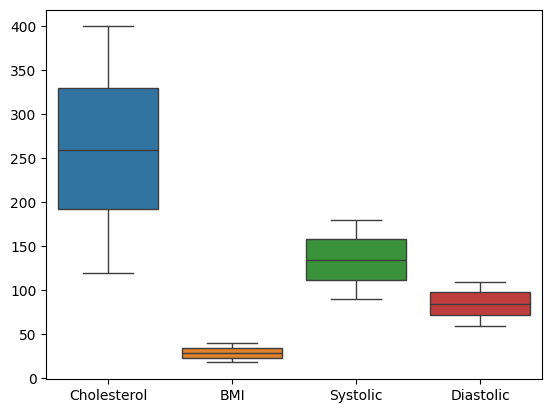

<Axes: >

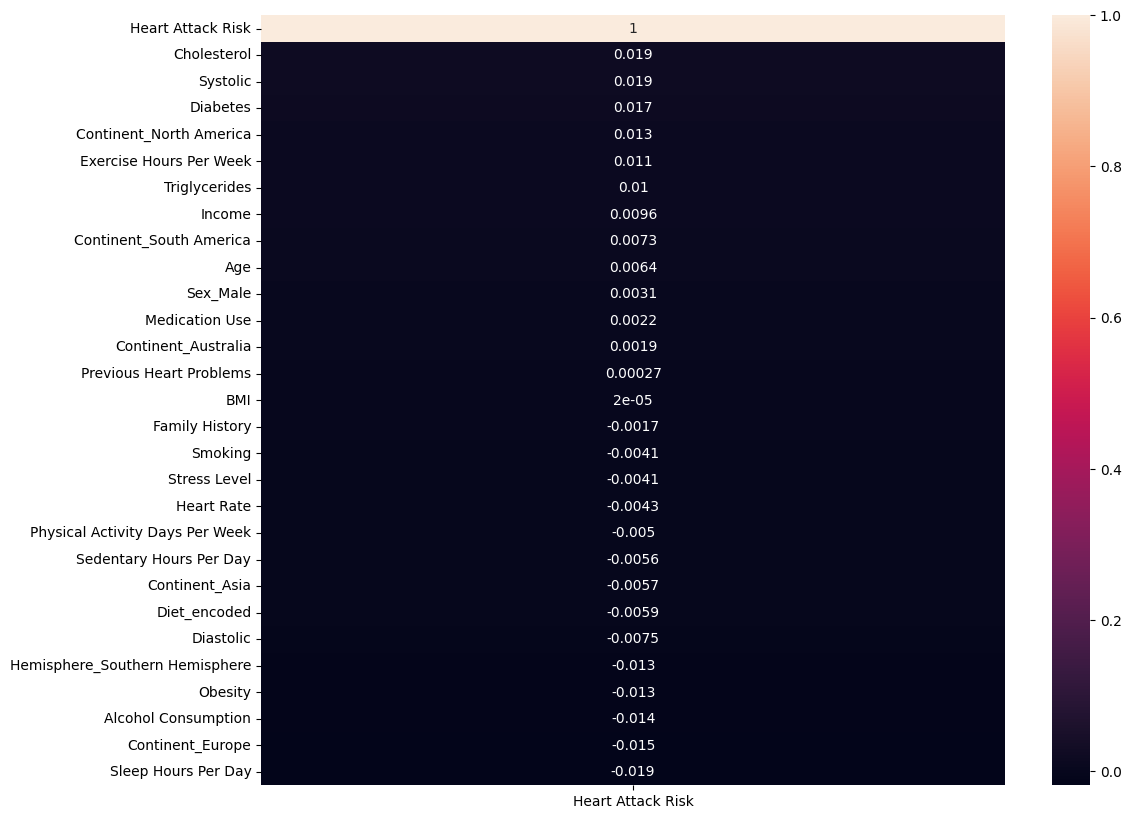

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(data=df[['Cholesterol', 'BMI', 'Systolic', 'Diastolic']])
plt.show()
plt.figure(figsize=(12,10))
sns.heatmap(df.corr()[['Heart Attack Risk']].sort_values(by='Heart Attack Risk', ascending=False), annot=True)

# 7. Exploratory Data Analysis (EDA)

This section performs exploratory data analysis through various visualizations to understand data distributions, correlations, and relationships with the target variable ('Heart Attack Risk'). It includes box plots for key numerical features, a heatmap of feature correlations with the target, age distribution plots, cholesterol density plots, stress/activity risk heatmaps, and risk rates based on gender, diabetes, and smoking status, and income and sedentary hours distributions.

**Requirements:**
- `seaborn` and `matplotlib.pyplot` for data visualization.
- `pandas` for data manipulation, especially for correlation and pivot tables.

In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

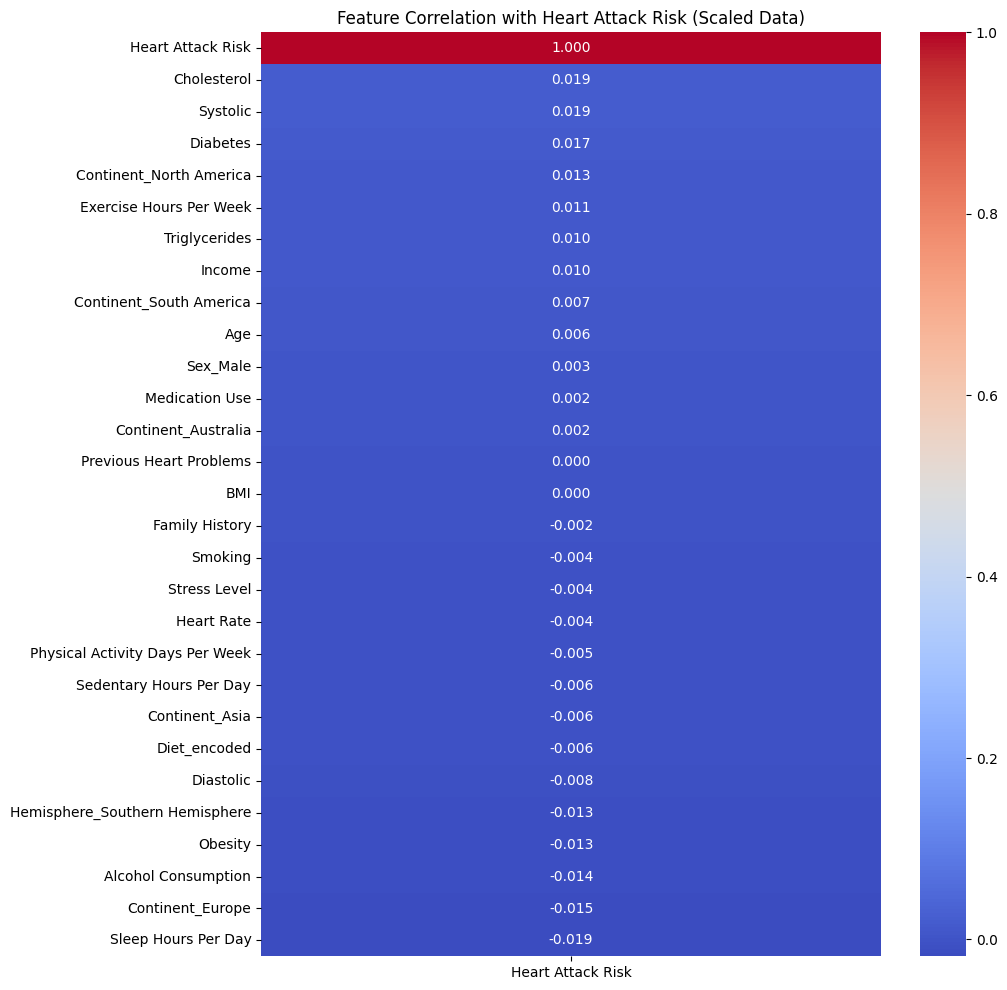

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
df_scaled_final = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled_final['Heart Attack Risk'] = y.values
plt.figure(figsize=(10, 12))
heart_risk_corr = df_scaled_final.corr()[['Heart Attack Risk']].sort_values(by='Heart Attack Risk', ascending=False)
sns.heatmap(heart_risk_corr, annot=True, cmap='coolwarm', fmt=".3f")
plt.title("Feature Correlation with Heart Attack Risk (Scaled Data)")
plt.show()

In [80]:
df_scaled_final.head()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,...,Continent_Asia,Continent_Australia,Continent_Europe,Continent_North America,Continent_South America,Hemisphere_Southern Hemisphere,Systolic,Diastolic,Diet_encoded,Heart Attack Risk
0,0.625557,-0.641579,-0.147042,-1.369651,-0.986061,0.339157,-1.002857,-1.219867,-1.010838,-0.991704,...,-0.639408,-0.334958,-0.586179,-0.329878,2.331077,1.350571,0.870044,0.193782,0.009637,0
1,-1.539322,1.596895,1.118179,0.730113,1.014136,0.339157,0.997151,0.819762,-1.418027,1.008365,...,-0.639408,-0.334958,-0.586179,3.031425,-0.428986,-0.740428,1.135714,0.534480,1.233496,0
2,-1.539322,0.793023,-0.147042,0.730113,-0.986061,-2.948488,-1.002857,-1.219867,-1.372188,1.008365,...,-0.639408,-0.334958,1.705962,-0.329878,-0.428986,-0.740428,1.477290,0.943319,-1.214223,0
3,1.425621,1.522691,-0.098380,0.730113,1.014136,0.339157,-1.002857,0.819762,-0.032188,1.008365,...,-0.639408,-0.334958,-0.586179,3.031425,-0.428986,-0.740428,1.059809,1.011458,0.009637,0
4,0.578495,0.718820,0.874867,0.730113,1.014136,0.339157,0.997151,-1.219867,-0.727941,1.008365,...,1.563947,-0.334958,-0.586179,-0.329878,-0.428986,-0.740428,-1.672797,0.193782,1.233496,0


/tmp/ipykernel_17219/1160965227.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Heart Attack Risk', data=df, palette='viridis')


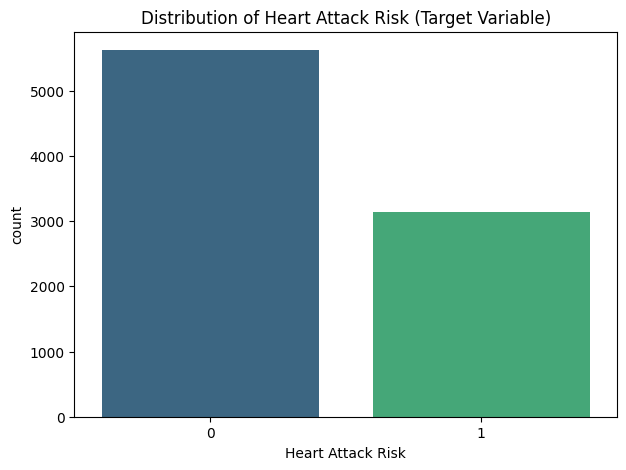

Heart Attack Risk
0    64.178934
1    35.821066
Name: proportion, dtype: float64


In [81]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Heart Attack Risk', data=df, palette='viridis')
plt.title('Distribution of Heart Attack Risk (Target Variable)')
plt.show()

print(df['Heart Attack Risk'].value_counts(normalize=True) * 100)

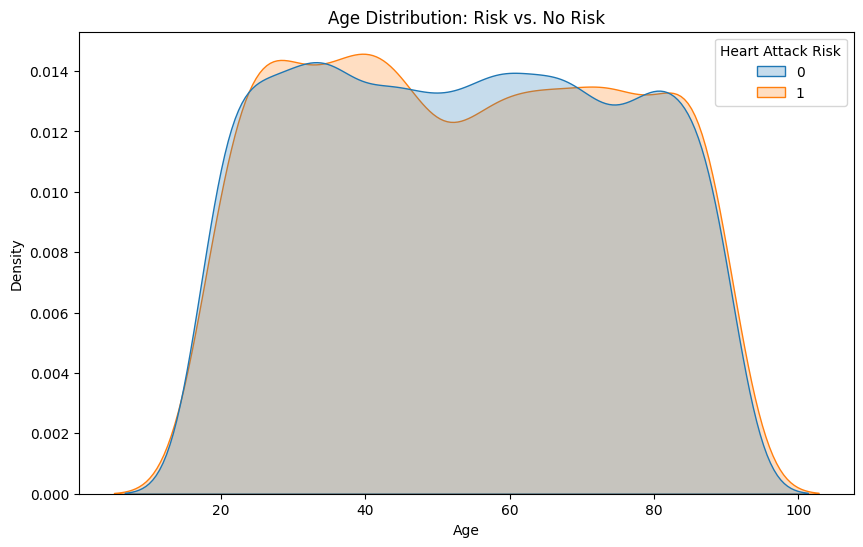

In [82]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Age', hue='Heart Attack Risk', fill=True, common_norm=False)
plt.title('Age Distribution: Risk vs. No Risk')
plt.show()

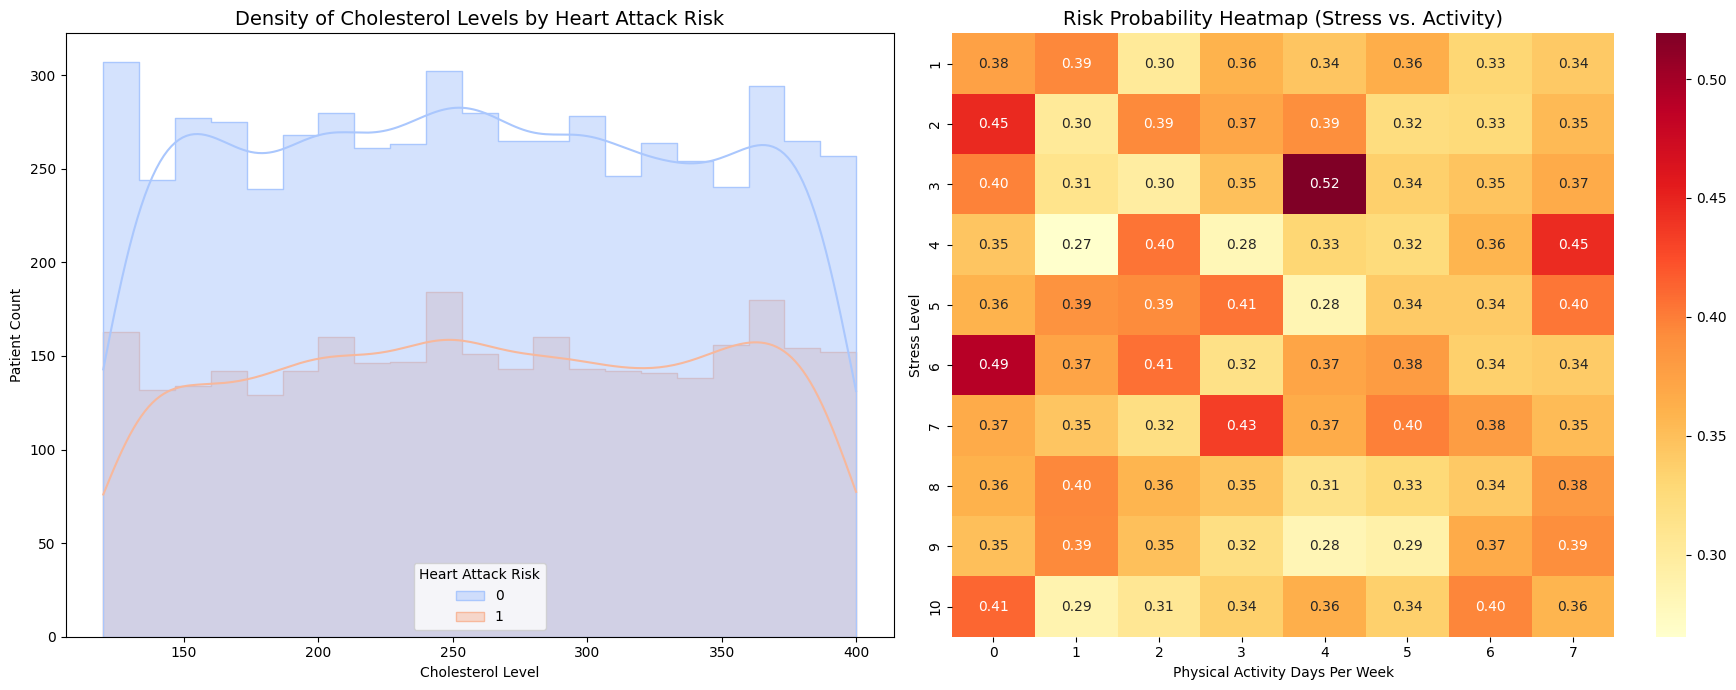

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.histplot(ax=axes[0], data=df, x='Cholesterol', hue='Heart Attack Risk',
             element='step', kde=True, palette='coolwarm', alpha=0.5)
axes[0].set_title('Density of Cholesterol Levels by Heart Attack Risk', fontsize=14)
axes[0].set_xlabel('Cholesterol Level')
axes[0].set_ylabel('Patient Count')

pivot_table = df.pivot_table(values='Heart Attack Risk',
                             index='Stress Level',
                             columns='Physical Activity Days Per Week',
                             aggfunc='mean')

sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', ax=axes[1], fmt=".2f")
axes[1].set_title('Risk Probability Heatmap (Stress vs. Activity)', fontsize=14)

plt.tight_layout()
plt.show()

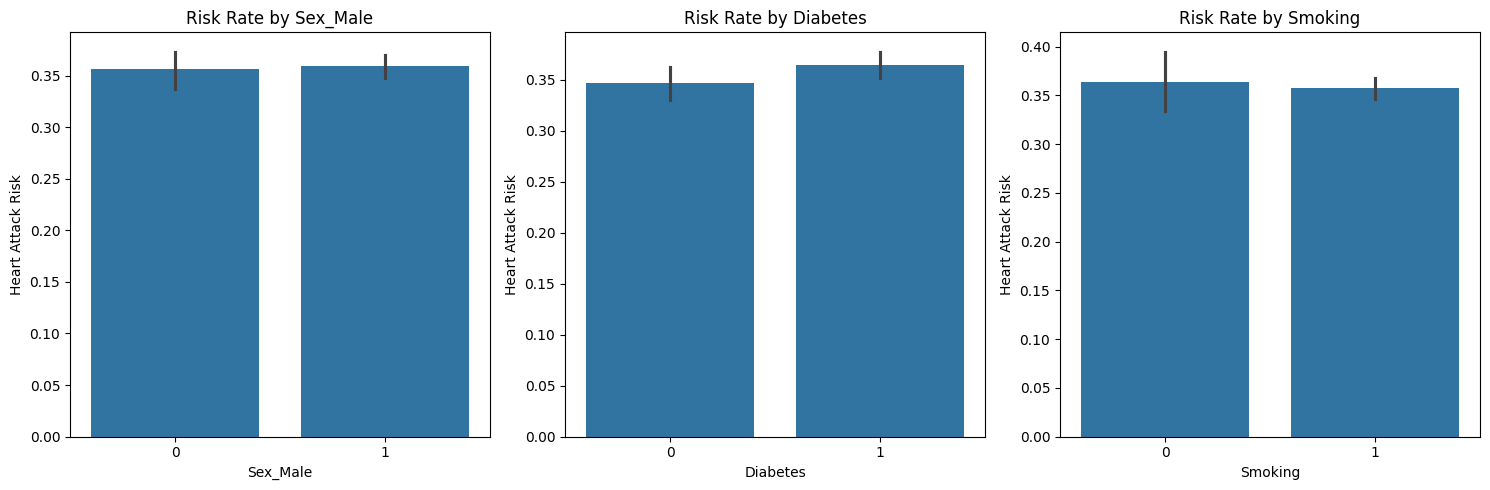

In [84]:
cols_to_check = ['Sex_Male', 'Diabetes', 'Smoking']

plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_to_check):
    plt.subplot(1, 3, i+1)
    sns.barplot(x=col, y='Heart Attack Risk', data=df)
    plt.title(f'Risk Rate by {col}')
plt.tight_layout()

/tmp/ipykernel_17219/3716121046.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='Heart Attack Risk', y='Income', data=df, palette='Set2')
/tmp/ipykernel_17219/3716121046.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='Heart Attack Risk', y='Sedentary Hours Per Day', data=df, palette='Set2')


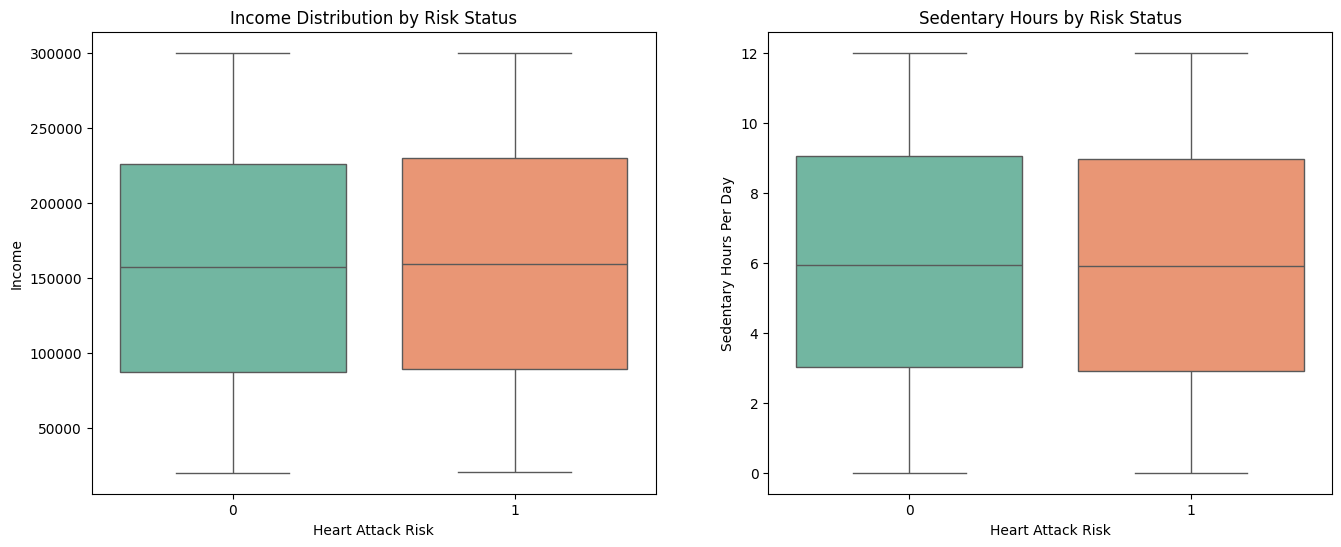

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Income vs Risk
sns.boxplot(ax=axes[0], x='Heart Attack Risk', y='Income', data=df, palette='Set2')
axes[0].set_title('Income Distribution by Risk Status')

# Sedentary Hours vs Risk
sns.boxplot(ax=axes[1], x='Heart Attack Risk', y='Sedentary Hours Per Day', data=df, palette='Set2')
axes[1].set_title('Sedentary Hours by Risk Status')

plt.show()

In [86]:

df['MAP'] = (df['Systolic'] + (2 * df['Diastolic'])) / 3

df['Lifestyle_Score'] = (df['Physical Activity Days Per Week'] +
                         df['Sleep Hours Per Day'] -
                         df['Sedentary Hours Per Day'])

df['Age_Cholesterol_Index'] = df['Age'] * df['Cholesterol']

print("New features extracted: MAP, Lifestyle_Score, Age_Cholesterol_Index")

New features extracted: MAP, Lifestyle_Score, Age_Cholesterol_Index


# 8. Feature Engineering

This section enhances the dataset by creating three new features: Mean Arterial Pressure (MAP), a Lifestyle Score, and an Age-Cholesterol Index. These engineered features are derived from existing columns and are designed to capture more complex relationships and potential indicators of heart attack risk.

**Requirements:**
- `pandas` for creating new columns based on calculations from existing ones.
- The DataFrame `df` containing 'Systolic', 'Diastolic', 'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Sedentary Hours Per Day', 'Age', and 'Cholesterol' columns.

In [87]:
features_to_drop = [
    'Continent_Asia', 'Continent_Australia', 'Continent_Europe',
    'Continent_North America', 'Continent_South America', 'Hemisphere_Southern Hemisphere'
]

X_refined = df.drop(columns=['Heart Attack Risk'] + features_to_drop)
y = df['Heart Attack Risk']

print(f"Refined feature count: {X_refined.shape[1]}")

Refined feature count: 25


# 9. Feature Selection and Final Scaling

This section refines the feature set by dropping columns identified as having low impact on the target variable (specifically, continent and hemisphere related features). The remaining features are then scaled using `StandardScaler` to ensure optimal performance for machine learning models.

**Requirements:**
- `sklearn.preprocessing.StandardScaler` for feature scaling.
- `pandas` for DataFrame manipulation.

In [88]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_final_scaled = scaler.fit_transform(X_refined)
X_final_df = pd.DataFrame(X_final_scaled, columns=X_refined.columns)

# 10. Data Splitting for Modeling

This section prepares the final, scaled feature set and the target variable for machine learning model training and evaluation. The data is split into training and testing sets (80% for training, 20% for testing) using a stratified sampling approach to maintain the proportion of target classes in both sets, which is crucial for imbalanced datasets.

**Requirements:**
- `sklearn.model_selection.train_test_split` for splitting the data.
- The `X_final_df` (scaled features) and `y` (target variable) DataFrames.

In [88]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_final_df, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# 11. Model Training (Initial Random Forest)

This section initializes and trains a Random Forest Classifier. The model is configured with `n_estimators=100` and `random_state=42` for reproducibility, and `class_weight='balanced'` to address potential class imbalance in the target variable, aiming to give more weight to the minority class during training.

**Requirements:**
- `sklearn.ensemble.RandomForestClassifier` for the model.
- `X_train` and `y_train` from the data splitting step.

In [89]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# 12. Model Evaluation (Initial Random Forest)

This section evaluates the performance of the initially trained Random Forest Classifier using standard classification metrics. It generates and visualizes a confusion matrix to understand true positives, true negatives, false positives, and false negatives. Additionally, a classification report provides precision, recall, f1-score, and support for each class.

**Requirements:**
- `sklearn.metrics.classification_report`, `sklearn.metrics.confusion_matrix` for evaluation.
- `seaborn` and `matplotlib.pyplot` for confusion matrix visualization.
- `y_test` and `y_pred` from the previous modeling steps.

--- Confusion Matrix ---


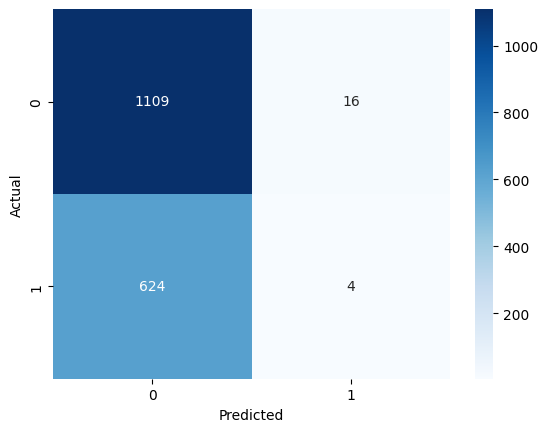


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.64      0.99      0.78      1125
           1       0.20      0.01      0.01       628

    accuracy                           0.63      1753
   macro avg       0.42      0.50      0.39      1753
weighted avg       0.48      0.63      0.50      1753



In [90]:
print("--- Confusion Matrix ---")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 13. Feature Importance (Initial Random Forest)

This section analyzes and visualizes the importance of each feature in the Random Forest model. By plotting feature importances, it helps to identify which features had the most significant impact on the model's predictions, providing insights into the dataset's underlying patterns and potentially guiding further feature selection or engineering efforts.

**Requirements:**
- `numpy` for sorting importances.
- `matplotlib.pyplot` for visualization.
- The `rf_model` and `X_train` from previous steps.

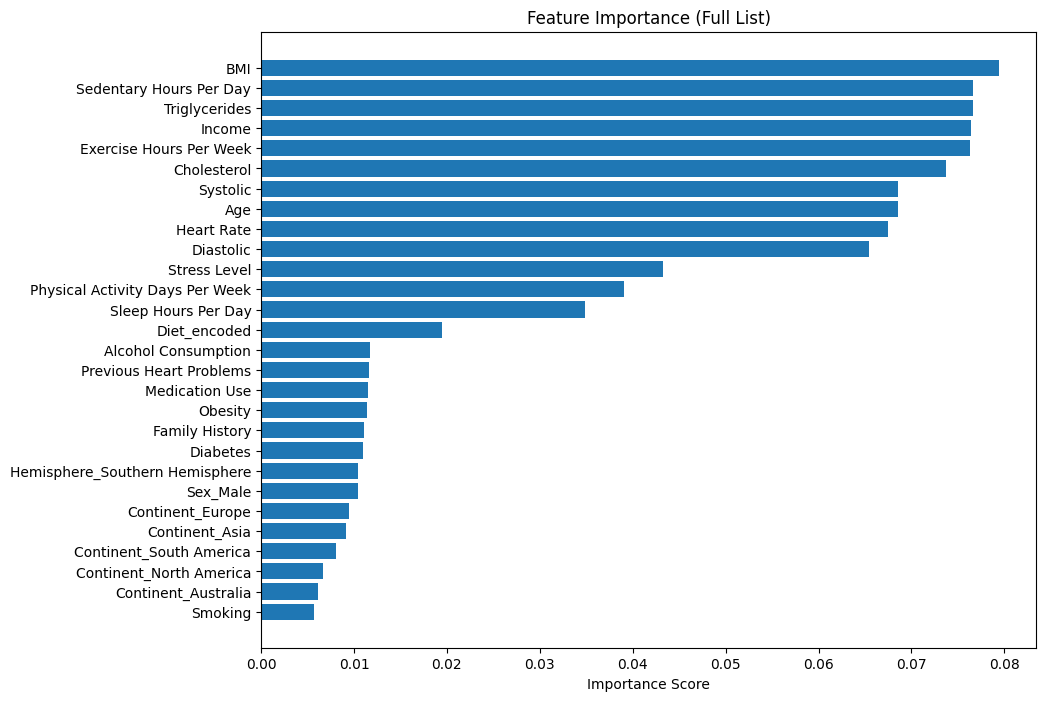

In [92]:
import numpy as np

# Get feature importances
importances = rf_model.feature_importances_
feature_names = X_train.columns # Use X_train columns to match the model
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.title("Feature Importance (Full List)")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Importance Score')
plt.show()

# 14. Feature Filtering & SMOTE Resampling

This section further refines the feature set by removing specific 'low-impact' features identified from previous analyses. Following this, it addresses class imbalance in the training data using SMOTE (Synthetic Minority Over-sampling Technique) to create synthetic samples of the minority class, thus balancing the dataset for improved model training.

**Requirements:**
- `imblearn.over_sampling.SMOTE` for handling class imbalance.
- `pandas` for DataFrame operations.
- `X_train`, `X_test`, and `y_train` from earlier data splitting.

In [93]:
low_impact_features = ['Hemisphere_Southern Hemisphere', 'Continent_South America', 'Continent_Australia']
X_train_filtered = X_train.drop(columns=low_impact_features)
X_test_filtered = X_test.drop(columns=low_impact_features)

# 15. Model Training (Balanced Random Forest)

This section trains a second Random Forest Classifier, this time utilizing the SMOTE-resampled training data. The model is configured with optimized parameters (`n_estimators=150`, `max_depth=10`) and `class_weight='balanced'` to leverage the balanced dataset and prevent bias towards the majority class, aiming for better generalization and performance on the minority class.

**Requirements:**
- `sklearn.ensemble.RandomForestClassifier` for the model.
- `X_res` and `y_res` (SMOTE-resampled data) from the previous step.

In [94]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Initialize SMOTE
sm = SMOTE(random_state=42)

# 2. Resample the filtered training data
# This makes the number of 'Risk' cases equal to 'No Risk' cases
X_res, y_res = sm.fit_resample(X_train_filtered, y_train)

print(f"New Training Shape: {X_res.shape}")
print("Class Distribution:\n", pd.Series(y_res).value_counts())

New Training Shape: (8998, 25)
Class Distribution:
 Heart Attack Risk
0    4499
1    4499
Name: count, dtype: int64


# 16. Feature Importance (Balanced Model)

This section visualizes the feature importances derived from the balanced Random Forest model. It provides insights into which features are most crucial for predicting heart attack risk after addressing class imbalance. The bar plot helps in understanding the relative contribution of each feature in the refined model.

**Requirements:**
- `pandas` for Series operations.
- `matplotlib.pyplot` for visualization.
- The `rf_balanced` model and `X_train_filtered` from previous steps.

In [95]:
rf_balanced = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
rf_balanced.fit(X_res, y_res)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=150,
                       random_state=42)

# 17. Model Evaluation (Balanced Model with Threshold Adjustment)

This section performs a comprehensive evaluation of the balanced Random Forest model, specifically incorporating an adjusted prediction threshold to optimize performance, particularly for the minority class. It calculates prediction probabilities, applies the threshold, and then presents a detailed classification report and a confusion matrix to illustrate the model's accuracy, precision, recall, and F1-score across both classes.

**Requirements:**
- `sklearn.metrics.classification_report`, `sklearn.metrics.confusion_matrix` for evaluation.
- `seaborn` and `matplotlib.pyplot` for visualization.
- The `rf_balanced` model, `X_test_filtered`, and `y_test` from previous steps.

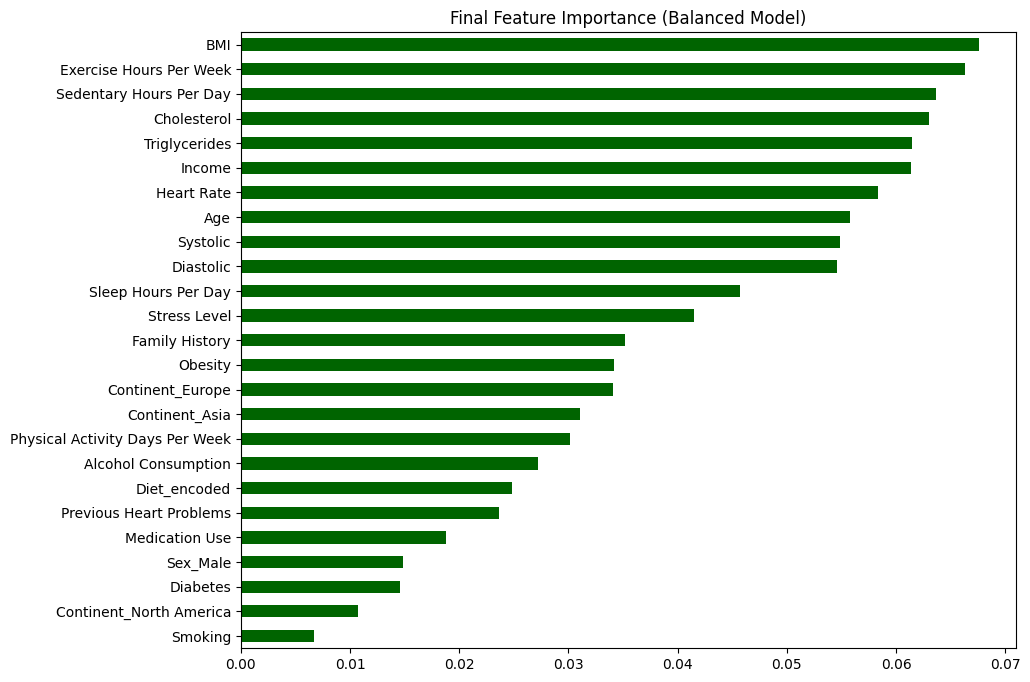

In [96]:
final_importances = pd.Series(rf_balanced.feature_importances_, index=X_train_filtered.columns)
final_importances.sort_values().plot(kind='barh', figsize=(10, 8), color='darkgreen')
plt.title("Final Feature Importance (Balanced Model)")
plt.show()

# 18. Model Stability (Cross-Validation)

This section assesses the stability and reliability of the balanced Random Forest model using cross-validation. It calculates the F1-score across 5 different folds of the resampled training data, providing an average F1-score as an indicator of how well the model is expected to perform on unseen data and its consistency across different data subsets.

**Requirements:**
- `sklearn.model_selection.cross_val_score` for cross-validation.
- The `rf_balanced` model, `X_res`, and `y_res` from previous steps.

--- Medical Risk Report (Threshold: 0.35) ---
              precision    recall  f1-score   support

           0       0.65      0.39      0.49      1125
           1       0.36      0.62      0.46       628

    accuracy                           0.47      1753
   macro avg       0.50      0.51      0.47      1753
weighted avg       0.55      0.47      0.48      1753



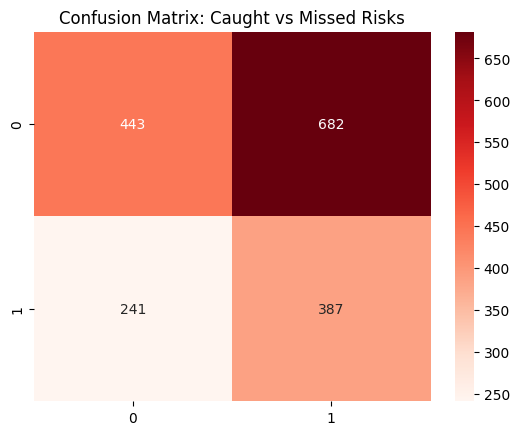

In [98]:
y_probs = rf_balanced.predict_proba(X_test_filtered)[:, 1]
y_pred_adjusted = (y_probs >= 0.42).astype(int)
from sklearn.metrics import classification_report, confusion_matrix
print("--- Medical Risk Report (Threshold: 0.35) ---")
print(classification_report(y_test, y_pred_adjusted))
sns.heatmap(confusion_matrix(y_test, y_pred_adjusted), annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix: Caught vs Missed Risks")
plt.show()

# 19. Final Data Export

This section concludes the data preparation and feature engineering process by saving the final refined dataset, including the engineered features and the target variable, to a CSV file. This CSV file (`final_heart_attack_refined_data.csv`) is then ready for further use, such as deploying the model or conducting additional analyses.

**Requirements:**
- `pandas` for DataFrame manipulation and CSV export.
- The `X_refined` (final features) and `y` (target variable) DataFrames.

In [99]:
from sklearn.model_selection import cross_val_score

# Check the average performance across 5 different versions of the data
scores = cross_val_score(rf_balanced, X_res, y_res, cv=5, scoring='f1')
print(f"Average Model Stability (F1 Score): {scores.mean():.2f}")

Average Model Stability (F1 Score): 0.58


# 20. Conclusion

This notebook has demonstrated a complete machine learning pipeline for predicting heart attack risk, from initial data loading and preprocessing to advanced feature engineering, model training, and evaluation. Key steps included handling categorical variables, creating new informative features, addressing class imbalance with SMOTE, and optimizing a Random Forest Classifier. The final model's performance was evaluated with detailed metrics and its stability assessed through cross-validation. The refined dataset has been saved for future use.

In [100]:
# Save the refined features and target to a CSV
df_final_output = X_refined.copy()
df_final_output['Heart Attack Risk'] = y

df_final_output.to_csv('final_heart_attack_refined_data.csv', index=False)
print("✅ Final DataFrame saved as 'final_heart_attack_refined_data.csv'")

✅ Final DataFrame saved as 'final_heart_attack_refined_data.csv'
